# Validate Input-Data Stores

This notebook performs a quick visual and statistical sanity check on the unified icechunk
stores produced by the ETL pipelines in `src/srm/input_data/`. Each pipeline ingests raw
GCM/observational output, harmonizes calendars, units, and ensemble-member identifiers, and
writes a single per-source icechunk store consumed by the BCSD pipeline's
`prepare_observations` and `fit_historical` stages.

Sources covered:

| Source | Module | Store |
|---|---|---|
| ERA5 (observations) | `src/srm/input_data/era5.py` | `s3://carbonplan-srm/input/processed/era5.icechunk` |
| CESM2-WACCM | `src/srm/input_data/cesm2_waccm.py` | `s3://carbonplan-srm/input/processed/cesm2-waccm.icechunk` |
| MIROC-ES2H | `src/srm/input_data/miroc.py` | `s3://carbonplan-srm/input/processed/miroc-es2h.icechunk` |
| UKESM1-0-LL | `src/srm/input_data/ukesm.py` | `s3://carbonplan-srm/input/processed/ukesm.icechunk` |

For each source we open the store read-only, inspect its structure, and run a handful of
lightweight checks (spatial maps, ensemble/time coverage, physical-constraint violations).
All checks operate on small slices or single grid points so they can run without a Coiled
cluster — full-array reductions over the multi-hundred-GB variables are deliberately avoided.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import qaqc
from srm.qaqc import (
    check_ensemble_spread,
    check_units_and_range,
    point_missingness,
    summarize_grid,
    summarize_time_coverage,
)

BUCKET = "carbonplan-srm"


def open_unified_store(prefix: str, bucket: str = BUCKET):
    """Open a unified icechunk store read-only as a DataTree (or Dataset if flat)."""
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    try:
        obj = xr.open_datatree(session.store, engine="zarr", chunks="auto")
    except Exception:
        obj = xr.open_dataset(session.store, engine="zarr", chunks="auto")
    return repo, obj


def summarize_groups(dt: xr.DataTree) -> pd.DataFrame:
    """One row per group/scenario: members, time range, grid shape, variables."""
    rows = []
    for name, node in dt.children.items():
        ds = node.to_dataset()
        rows.append(
            {
                "group": name,
                "ensemble_members": ds.sizes.get("ensemble_member"),
                "n_time": ds.sizes.get("time"),
                "time_start": str(ds.time.values[0])[:10],
                "time_end": str(ds.time.values[-1])[:10],
                "lat x lon": f"{ds.sizes['lat']} x {ds.sizes['lon']}",
                "variables": ", ".join(sorted(ds.data_vars)),
            }
        )
    return pd.DataFrame(rows).set_index("group")


def plot_missingness(mask: xr.DataArray, title: str, freq: str = "YS"):
    """Heatmap of fraction-missing per ensemble member, resampled along time."""
    frac = mask.resample(time=freq).mean()
    fig, ax = plt.subplots(figsize=(12, 0.6 * frac.sizes["ensemble_member"] + 1.5))
    im = ax.pcolormesh(
        frac.time,
        np.arange(frac.sizes["ensemble_member"]),
        frac.values,
        cmap="Reds",
        vmin=0,
        vmax=1,
    )
    ax.set_yticks(np.arange(frac.sizes["ensemble_member"]))
    ax.set_yticklabels(frac.ensemble_member.values)
    ax.set_xlabel("time")
    ax.set_ylabel("ensemble_member")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="fraction NaN")
    plt.tight_layout()


def highlight_fail(val):
    """Style helper: red background for any False in a min_ok/max_ok column."""
    return "background-color: #f8d7da" if val is False else ""


def highlight_row_fail(ok_col: str):
    """Style helper: red background for every cell in a row where `row[ok_col]` is False."""

    def _style(row):
        bad = not row[ok_col]
        return ["background-color: #f8d7da" if bad else "" for _ in row]

    return _style


def _sample_kwargs(ds, n_time: int = 10, seed: int = 42) -> dict | None:
    """Build isel_kwargs for representative sampling.

    Selects first and last ensemble member (when the dim is present) and a
    reproducible random sample of ``n_time`` time steps. Pass the result as
    ``isel_kwargs`` to ``check_units_and_range`` and similar helpers to get
    a fast but representative check instead of scanning the full dataset.
    """
    rng = np.random.default_rng(seed)
    kwargs: dict = {}
    if "ensemble_member" in ds.dims:
        kwargs["ensemble_member"] = [0, -1]
    if "time" in ds.dims:
        n = min(n_time, ds.sizes["time"])
        kwargs["time"] = sorted(rng.choice(ds.sizes["time"], size=n, replace=False).tolist())
    return kwargs if kwargs else None

## 1. ERA5: Observational Reference

`era5.py` builds the observational reference dataset used as the bias-correction target for
`prepare_observations`. For each variable it:

1. **Loads** hourly ERA5 data from the ARCO (Analysis-Ready, Cloud-Optimized) GCS archive via
   `load_era5` (or derives relative humidity from temperature + dewpoint via
   `load_hurs_from_era5`).
2. **Resamples to daily** frequency using a per-variable canonical operation
   (`resample_to_daily`) — e.g. mean for `tas`/`hurs`, max/min for `tasmax`/`tasmin`, sum for
   `pr`.
3. **Standardizes** coordinate and variable names to CMIP6 conventions (`preprocess_era5`):
   `latitude`/`longitude` → `lat`/`lon`, ERA5 variable names → `tas`, `tasmax`, `tasmin`,
   `pr`, `rsds`, etc.
4. **Writes** each variable into a single flat icechunk store at
   `OUTPUT_URI = s3://carbonplan-srm/input/processed/era5.icechunk`
   (`process_era5_var` / `process_era5_pipeline`), one variable per `to_icechunk` call so
   variables can be (re)processed independently.

Unlike the GCM stores below, the ERA5 store is **flat** — no zarr groups, no
`ensemble_member` dimension — just `(time, lat, lon)` on the native ~0.25° ERA5 grid
(`721 x 1440`), spanning 1950–2014.

In [2]:
storage = icechunk.s3_storage(bucket="carbonplan-srm", prefix="input/processed/era5.icechunk")
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")

In [3]:
ds = xr.open_dataset(session.store, engine="zarr", chunks="auto")
ds

<xarray.Dataset> Size: 789GB
Dimensions:      (time: 23741, lat: 721, lon: 1440, bounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 190kB 1950-01-01 ... 2014-12-31
  * lat          (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float32 6kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    lat_bounds   (lat, bounds) float32 6kB dask.array<chunksize=(721, 2), meta=np.ndarray>
    lon_bounds   (lon, bounds) float32 12kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    time_bounds  (time, bounds) datetime64[ns] 380kB dask.array<chunksize=(23741, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    hurs         (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    ps           (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    rsds         (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    rlds         (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tas          (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tasmax       (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    tasmin       (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>
    pr           (time, lat, lon) float32 99GB dask.array<chunksize=(32, 721, 1440), meta=np.ndarray>

### 1.1 Spatial sanity check

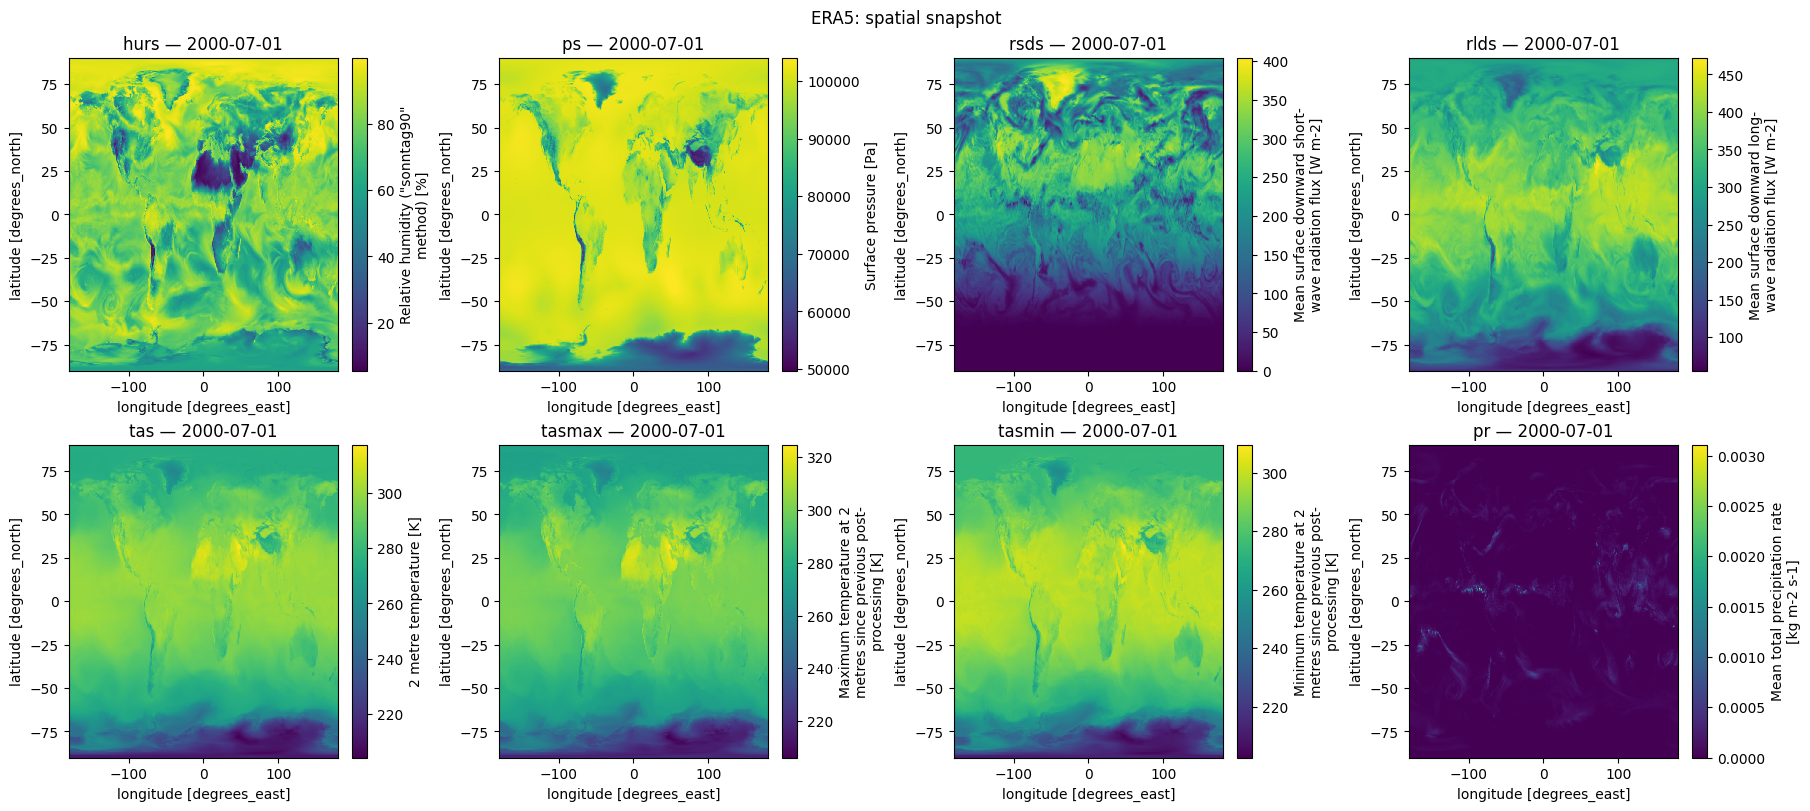

In [4]:
date = "2000-07-01"
variables = list(ds.data_vars)
fig, axes = plt.subplots(2, len(variables) // 2, figsize=(18, 8), constrained_layout=True)

for ax, var in zip(axes.ravel(), variables):
    ds[var].sel(time=date).plot(ax=ax, cmap="viridis")
    ax.set_title(f"{var} — {date}")
fig.suptitle("ERA5: spatial snapshot");

### 1.2 Time coverage check

In [5]:
expected = pd.date_range(ds.time.values[0], ds.time.values[-1], freq="D")
actual = pd.DatetimeIndex(ds.time.values)
print(f"Expected days: {len(expected)}, actual: {len(actual)}")
print(f"Missing days: {len(expected.difference(actual))}")
print(f"Duplicate days: {actual.duplicated().sum()}")
print(f"Monotonic increasing: {actual.is_monotonic_increasing}")

Expected days: 23741, actual: 23741
Missing days: 0
Duplicate days: 0
Monotonic increasing: True


### 1.3 Physical-constraint checks (one-year subset)

`src/srm/qaqc.py` provides `check_physical_constraints`, which flags negative/outlandish
precipitation, outlandish temperatures, and non-monotonic `tasmin <= tas <= tasmax`
relationships. We run it on a single year to keep the compute small.

In [6]:
era5_subset = ds.sel(time="2010").compute()
qaqc.check_physical_constraints(era5_subset)

Number of negative precipitation values: 0
Number of outlandishly high precipitation values: 0
Number of outlandishly high tas values: 0
Number of outlandishly high tasmax values: 0
Number of outlandishly high tasmin values: 0
Number of outlandishly low tas values: 0
Number of outlandishly low tasmax values: 0
Number of outlandishly low tasmin values: 0
Number of times tasmin exceeds tas: 5098890
Number of times tas exceeds tasmax: 3712149
Number of times tasmin exceeds tasmax: 0


## 2. CESM2-WACCM Store

`cesm2_waccm.py` produces a single unified icechunk store at
`UNIFIED_PREFIX = input/processed/cesm2-waccm.icechunk`, organized as **zarr groups** keyed by
scenario (`SCENARIO_TO_GROUP`):

| Scenario | Group |
|---|---|
| `historical` | `historical` |
| `pangeo-historical` | `historical` (merged in) |
| `ssp245` | `ssp245` |
| `G6-1.5K` | `g6_1p5k` |

Each scenario's raw NetCDF files are virtualized (`virtualizarr` + `HDFParser`) into
zarr-compatible references, materialized, calendar-converted to `proleptic_gregorian`
(`to_proleptic_gregorian` : handles `noleap` and `360_day` source calendars via
interpolation), and written with an `ensemble_member` dimension.

### The `historical` group: a two-source merge

The `historical` group combines two independent sources with different ensemble-member
identifiers and time spans:

- **ESGF member `'001'`** — all 6 variables (`tas`, `tasmax`, `tasmin`, `pr`, `rsds`, `hurs`),
  1978–2015.
- **Pangeo `pangeo-historical` members `r1i1p1f1`, `r2i1p1f1`, `r3i1p1f1`** — only
  `PANGEO_VARIABLES = ["tas", "rsds", "hurs", "pr"]` (no `tasmax`/`tasmin` — these don't exist
  for these members in any public archive), 1850–2015.

Because the two sources have different `ensemble_member` and `time` coordinates, appending
the Pangeo data directly with `to_icechunk(mode="a")` raised
`ValueError: variable 'tas' already exists with different dimension sizes`.
`merge_pangeo_into_historical` resolves this by **reindexing both datasets onto the union of
`ensemble_member` and `time` coordinates** and combining with `combine_first`, then
rewriting the group with `write_mode="w"`. The practical consequence (visible below):
`tasmax`/`tasmin` are `NaN` for the three Pangeo members, and all variables are `NaN` for
`'001'` outside its 1978–2015 span.

The `ssp245` and `g6_1p5k` groups follow the simpler single-source path
(`process_cesm_var` → `process_cesm_pipeline`), with one `ensemble_member` per ESGF variant
label (`'001'`–`'010'`).

In [7]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm", prefix="input/processed/cesm2-waccm.icechunk"
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session("main")

In [8]:
dt = xr.open_datatree(session.store, engine="zarr", chunks="auto")
dt

<xarray.DataTree>
Group: /
├── Group: /g6_1p5k
│       Dimensions:          (ensemble_member: 3, time: 18264, lat: 192, lon: 288)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 24B '001' '002' '003'
│         * time             (time) datetime64[ns] 146kB 2035-01-01 ... 2085-01-01
│         * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
│         * lon              (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
│       Data variables:
│           pr               (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│           tasmin           (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 180, 192, 288), meta=np.ndarray>
│       Attributes: (12/14)
│           Conventions:                CF-1.0
│           source:                     CAM
│           case:                       b.e21.BW.f09_g17.SSP245-G6-SAI-1p5.001
│           logname:                    walkerl
│           host:                       derecho4
│           initial_file:               b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WA...
│           ...                         ...
│           time_period_freq:           day_1
│           scenario:                   G6-1.5K
│           model:                      CESM2-WACCM
│           experiment_lineage:         unknown_parent -> G6-1.5K
│           ensemble_derivation_logic:  Ensemble member derived from filename case se...
│           processing_steps:           time_drop_duplicates, lon_to_180, lat_lon_sor...
├── Group: /historical
│       Dimensions:          (ensemble_member: 4, time: 60281, lat: 192, lon: 288)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 32B '001' ... 'r3i1p1f1'
│         * time             (time) datetime64[ns] 482kB 1850-01-01 ... 2015-01-16
│         * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
│         * lon              (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
│       Data variables:
│           pr               (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│           tasmin           (ensemble_member, time, lat, lon) float32 53GB dask.array<chunksize=(4, 150, 192, 288), meta=np.ndarray>
│       Attributes: (12/48)
│           Conventions:                CF-1.7 CMIP-6.2
│           source:                     CESM2 (2017): atmosphere: CAM6 (0.9x1.25 fini...
│           case:                       b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WA...
│           logname:                    tilmes
│           host:                       cheyenne2
│           initial_file:               b.e21.BWHIST.f09_g17.CMIP6-historical-WACCM.0...
│           ...                         ...
│           source_type:                AOGCM BGC CHEM AER
│           sub_experiment:     

### 2.1 Group summary

In [9]:
summarize_groups(dt)

,ensemble_members,n_time,time_start,time_end,lat x lon,variables
group,,,,,,
g6_1p5k,3,18264,2035-01-01,2085-01-01,192 x 288,"hurs, pr, rsds, tas, tasmax, tasmin"
historical,4,60281,1850-01-01,2015-01-16,192 x 288,"hurs, pr, rsds, tas, tasmax, tasmin"
ssp245,10,31046,2015-01-01,2099-12-31,192 x 288,"hurs, pr, rsds, tas, tasmax, tasmin"


### 2.2 `historical` group: merge coverage check

For each variable, plot the fraction of NaN years per ensemble member at a single grid
point. We expect `'001'` to be NaN outside 1978–2015 for every variable, and the three
Pangeo members (`r*i1p1f1`) to be NaN for `tasmax`/`tasmin` everywhere and for the other
variables outside 1850–2015.

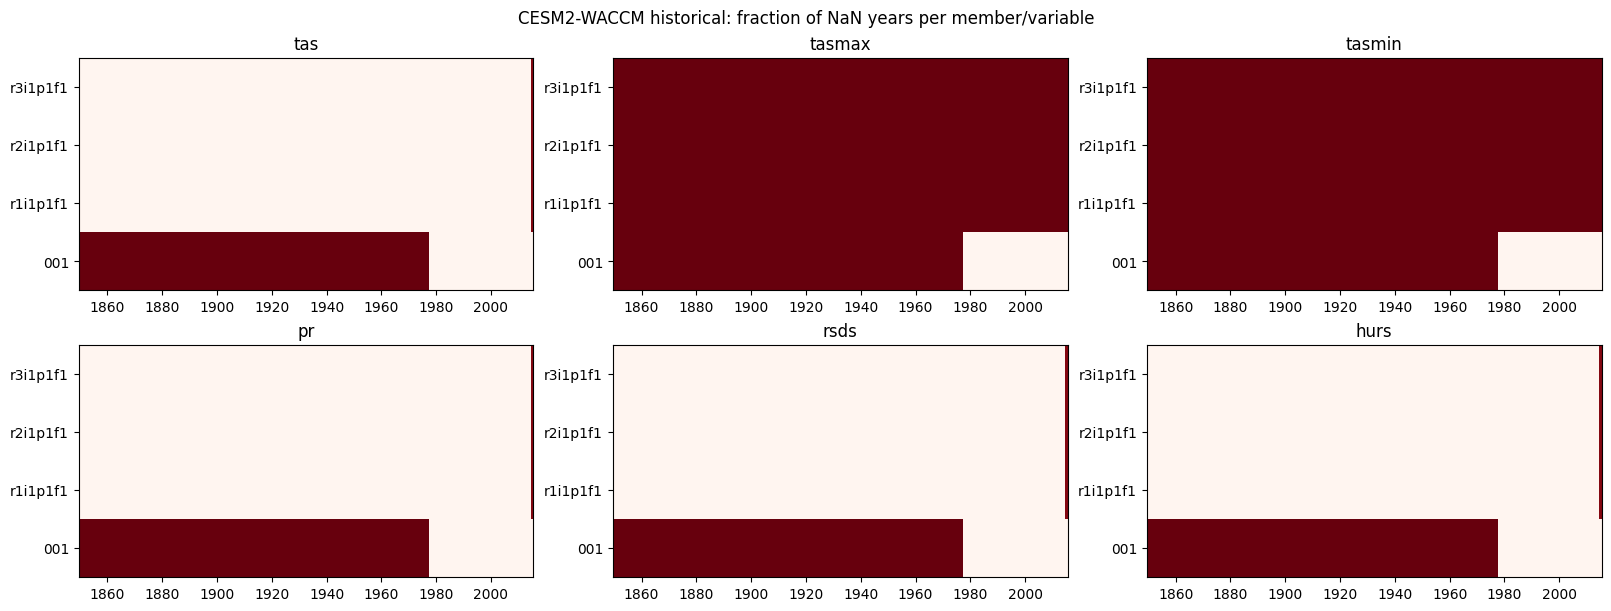

In [10]:
hist_cesm = dt["historical"].to_dataset()

fig, axes = plt.subplots(2, 3, figsize=(16, 6), constrained_layout=True)
for ax, var in zip(axes.ravel(), ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]):
    mask = point_missingness(hist_cesm, var)
    frac = mask.resample(time="YS").mean()
    im = ax.pcolormesh(
        frac.time,
        np.arange(frac.sizes["ensemble_member"]),
        frac.values,
        cmap="Reds",
        vmin=0,
        vmax=1,
    )
    ax.set_yticks(np.arange(frac.sizes["ensemble_member"]))
    ax.set_yticklabels(frac.ensemble_member.values)
    ax.set_title(var)
fig.suptitle("CESM2-WACCM historical: fraction of NaN years per member/variable");

### 2.3 Spatial comparison: ESGF `'001'` vs Pangeo `r1i1p1f1`

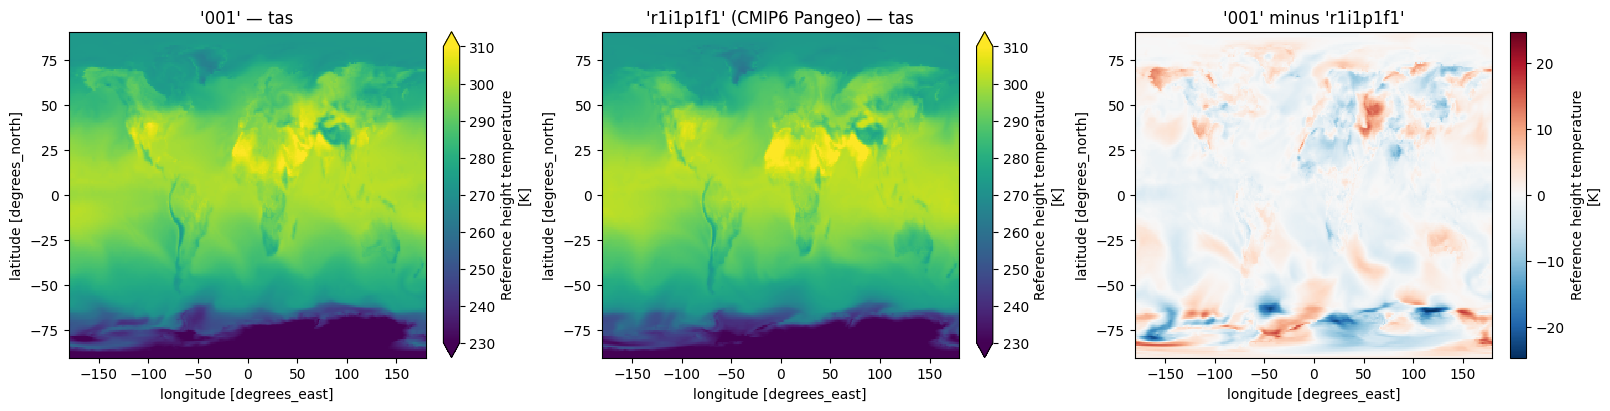

In [11]:
date = "2000-07-01"
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

da_001 = hist_cesm["tas"].sel(ensemble_member="001", time=date)
da_r1 = hist_cesm["tas"].sel(ensemble_member="r1i1p1f1", time=date)

da_001.plot(ax=axes[0], vmin=230, vmax=310)
axes[0].set_title("'001' — tas")

da_r1.plot(ax=axes[1], vmin=230, vmax=310)
axes[1].set_title("'r1i1p1f1' (CMIP6 Pangeo) — tas")

(da_001 - da_r1).plot(ax=axes[2], cmap="RdBu_r")
axes[2].set_title("'001' minus 'r1i1p1f1'");

### 2.4 Ensemble-mean time series across the merge

A continuous annual-mean time series at a single grid point should show all four members
tracking each other reasonably well, with `'001'` only appearing from 1978 onward.

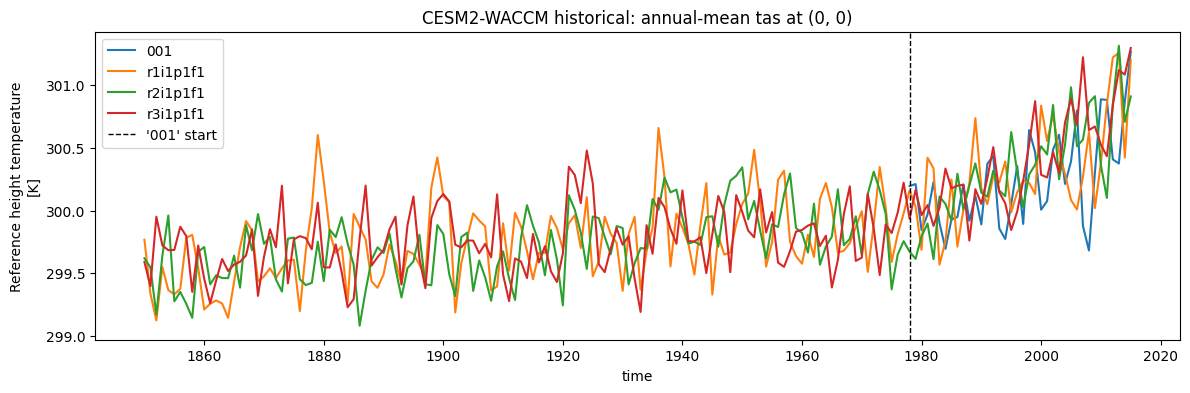

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
for member in hist_cesm.ensemble_member.values:
    da = (
        hist_cesm["tas"]
        .sel(ensemble_member=member)
        .sel(lat=0, lon=0, method="nearest")
        .resample(time="YS")
        .mean()
        .compute()
    )
    da.plot(ax=ax, label=str(member))
ax.axvline(pd.Timestamp("1978-01-01"), color="k", ls="--", lw=1, label="'001' start")
ax.legend()
ax.set_title("CESM2-WACCM historical: annual-mean tas at (0, 0)");

### 2.5 `ssp245` group: completeness check

`ssp245` was still being populated when this notebook was first written (only `tas` was
present). All 6 variables and all 10 members have since landed — confirm completeness and
check for residual structural NaNs.

In [13]:
ssp_cesm = dt["ssp245"].to_dataset()
print("Variables present in ssp245 group:", sorted(ssp_cesm.data_vars))
print("Members:", list(ssp_cesm.ensemble_member.values))
print(f"Time range: {str(ssp_cesm.time.values[0])[:10]} -> {str(ssp_cesm.time.values[-1])[:10]}")

for var in sorted(ssp_cesm.data_vars):
    mask = point_missingness(ssp_cesm, var)
    print(f"{var}: NaN fraction at (0, 0) = {float(mask.mean()):.4%}")

Variables present in ssp245 group: ['hurs', 'pr', 'rsds', 'tas', 'tasmax', 'tasmin']
Members: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
Time range: 2015-01-01 -> 2099-12-31
hurs: NaN fraction at (0, 0) = 17.6451%
pr: NaN fraction at (0, 0) = 17.6451%
rsds: NaN fraction at (0, 0) = 17.6451%
tas: NaN fraction at (0, 0) = 17.6451%
tasmax: NaN fraction at (0, 0) = 17.6451%
tasmin: NaN fraction at (0, 0) = 17.6451%


## 3. MIROC-ES2H Store

`miroc.py` mirrors the CESM2-WACCM structure: a unified store at
`UNIFIED_PREFIX = input/processed/miroc-es2h.icechunk` with groups `historical`, `ssp245`,
`g6_1p5k` (`SCENARIO_TO_GROUP`). All 6 `MIROC_VARIABLES`
(`hurs`, `pr`, `rsds`, `tas`, `tasmax`, `tasmin`) are processed for every scenario.

Two notable pipeline behaviors:

- **`hurs` units** : `CMORIZE_HURS` converts `hurs` from a 0–1 fraction to percent for
  scenarios where it isn't already in percent (`historical` is left as-is; others are
  multiplied by 100 via `cmorize_miroc`).
- **`ssp245` gap-stitching** : GeoMIP baseline runs (10 members, `r01`–`r10`) start in 2020,
  leaving a 2015–2019 gap relative to the historical record. `_load_ssp245_with_gap_fill`
  bridges this gap using `esgf-ssp245` (members `r1i1p4f2`, `r2i1p4f2`, `r3i1p4f2`,
  2015–2019), relabelling each ESGF bridge member to the GeoMIP member it feeds via
  `_SSP245_ESGF_MEMBER`, and `xr.concat`-ing `[gap_ds, geomip]` along `time`. The result is a
  continuous 2015–2100 `ssp245` group with **no structural gap** — unlike CESM2-WACCM's
  `historical` group, there should be no merge-induced NaNs here, which is worth confirming
  below.

`historical` (3 members, `r1i1p4f2`/`r2i1p4f2`/`r3i1p4f2`) and `g6_1p5k` (10 members,
`r01`–`r10`) follow the simpler single-source path.

In [14]:
storage = icechunk.s3_storage(bucket="carbonplan-srm", prefix="input/processed/miroc-es2h.icechunk")
repo_miroc = icechunk.Repository.open(storage)
session_miroc = repo_miroc.readonly_session("main")
dt_miroc = xr.open_datatree(session_miroc.store, engine="zarr", chunks="auto")
dt_miroc

<xarray.DataTree>
Group: /
├── Group: /esgf_ssp245
│       Dimensions:          (ensemble_member: 3, time: 31046, lat: 128, lon: 256)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 24B 'r1i1p4f2' ... 'r3i1p4f2'
│         * time             (time) datetime64[ns] 248kB 2015-01-01T12:00:00 ... 2099...
│         * lat              (lat) float64 1kB -88.93 -87.54 -86.14 ... 87.54 88.93
│         * lon              (lon) float64 2kB -180.0 -178.6 -177.2 ... 177.2 178.6
│       Data variables:
│           tasmin           (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 300, 128, 256), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 300, 128, 256), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 300, 128, 256), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 300, 128, 256), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 300, 128, 256), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 12GB dask.array<chunksize=(3, 300, 128, 256), meta=np.ndarray>
│       Attributes: (12/48)
│           Conventions:                CF-1.8
│           activity_id:                ScenarioMIP
│           branch_method:              standard
│           branch_time_in_child:       60265.0
│           branch_time_in_parent:      60265.0
│           creation_date:              2023-08-10T10:05:30Z
│           ...                         ...
│           cmor_version:               3.3.2
│           tracking_id:                hdl:21.14100/de789be9-beb6-4546-a0a8-8950c33f...
│           scenario:                   esgf-ssp245
│           model:                      MIROC-ES2H
│           time_range:                 2015-2099
│           ensemble_derivation_logic:  Extracted from CMIP6 DRS filename: url.split(...
├── Group: /g6_1p5k
│       Dimensions:          (ensemble_member: 10, time: 18263, lat: 128, lon: 256)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 80B 'r01' 'r02' ... 'r09' 'r10'
│         * time             (time) datetime64[ns] 146kB 2035-01-01T12:00:00 ... 2084...
│         * lat              (lat) float64 1kB -88.93 -87.54 -86.14 ... 87.54 88.93
│         * lon              (lon) float64 2kB -180.0 -178.6 -177.2 ... 177.2 178.6
│       Data variables:
│           hurs             (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│           tasmin           (ensemble_member, time, lat, lon) float32 24GB dask.array<chunksize=(5, 150, 128, 256), meta=np.ndarray>
│       Attributes: (12/14)
│           Conventions:                CF-1.8
│           title:                      MIROC-ES2H GeoMIP EXPERIMENT DATA
│           model_id:                   MIROC-ES2H
│           source:                     MIROC-ES2H (2023): \naerosol: SPRINTARS6.0\na...
│           institute_id:               MIROC
│           instituion:                 JAMSTEC (Japan Agency for Marine-Earth Scienc...
│           ...                         ...
│           references:                 MIROC-ES2H : Kawamiya, M., Hajima, T., Tachii...
│           experiment_id:              GeoMIP
│           license:  

### 3.1 Group summary

In [15]:
summarize_groups(dt_miroc)

,ensemble_members,n_time,time_start,time_end,lat x lon,variables
group,,,,,,
esgf_ssp245,3,31046,2015-01-01,2099-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"
g6_1p5k,10,18263,2035-01-01,2084-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"
ssp245,10,25568,2015-01-01,2084-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"
historical,3,60265,1850-01-01,2014-12-31,128 x 256,"hurs, pr, rsds, tas, tasmax, tasmin"


### 3.2 `ssp245` stitch boundary: continuity check (2015–2020)

Unlike the CESM2-WACCM `historical` merge, the MIROC `ssp245` gap-fill is a `concat` along
`time` onto disjoint member sets that are then relabelled to align — the result should be
**gap-free**. The heatmap below should show all-zero (white) NaN fraction across the
2015–2020 boundary.

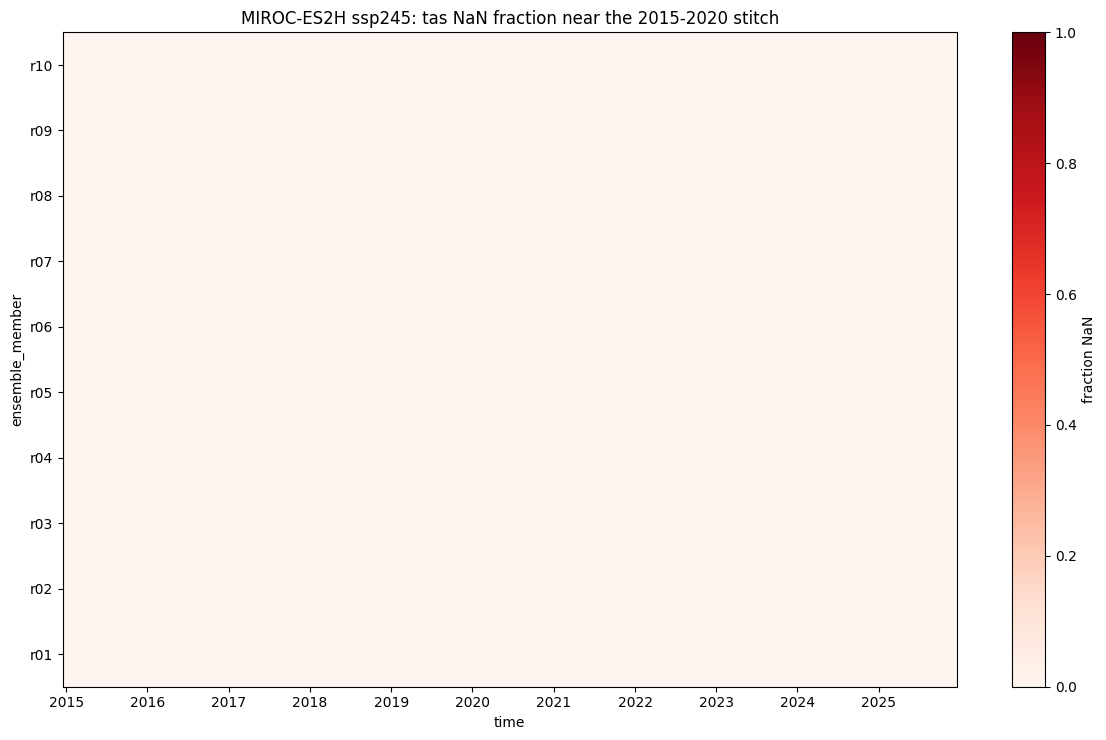

In [16]:
ssp_miroc = dt_miroc["ssp245"].to_dataset()
mask = point_missingness(ssp_miroc, "tas").sel(time=slice("2010", "2025"))
plot_missingness(mask, "MIROC-ES2H ssp245: tas NaN fraction near the 2015-2020 stitch", freq="MS")

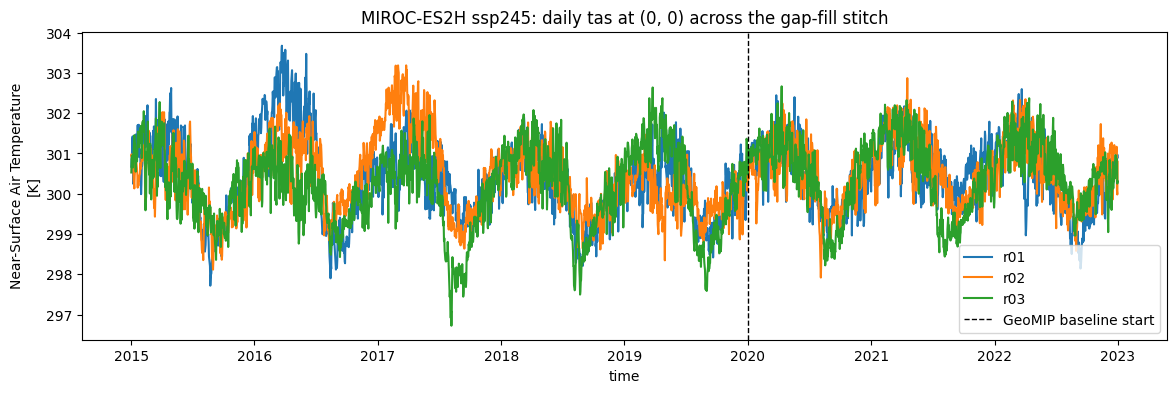

In [17]:
fig, ax = plt.subplots(figsize=(14, 4))
for member in ssp_miroc.ensemble_member.values[:3]:
    da = (
        ssp_miroc["tas"]
        .sel(ensemble_member=member)
        .sel(lat=0, lon=0, method="nearest")
        .sel(time=slice("2014", "2022"))
        .compute()
    )
    da.plot(ax=ax, label=str(member))
ax.axvline(pd.Timestamp("2020-01-01"), color="k", ls="--", lw=1, label="GeoMIP baseline start")
ax.legend()
ax.set_title("MIROC-ES2H ssp245: daily tas at (0, 0) across the gap-fill stitch");

### 3.3 Spatial sanity check

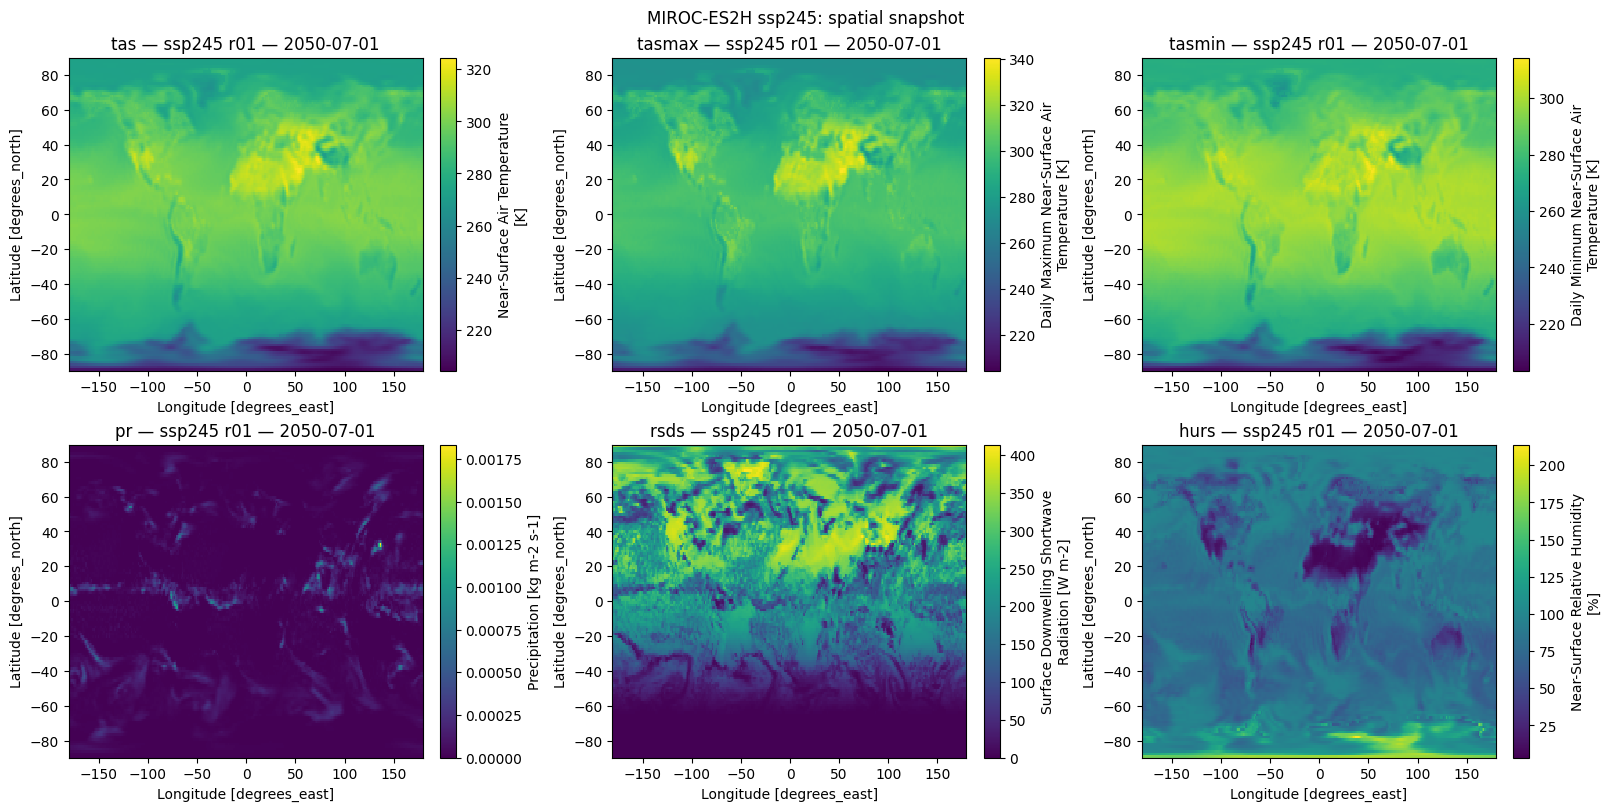

In [18]:
date = "2050-07-01"
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, var in zip(axes.ravel(), ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]):
    ssp_miroc[var].sel(ensemble_member="r01", time=date).plot(ax=ax, cmap="viridis")
    ax.set_title(f"{var} — ssp245 r01 — {date}")
fig.suptitle("MIROC-ES2H ssp245: spatial snapshot");

## 4. UKESM Store

`ukesm.py` mirrors the CESM2-WACCM/MIROC-ES2H structure: a unified store at
`UNIFIED_PREFIX = input/processed/ukesm.icechunk` with groups `historical`, `ssp245`,
`g6_1p5k` (`SCENARIO_TO_GROUP`). All 6 `UKESM_VARIABLES`
(`tas`, `tasmax`, `tasmin`, `pr`, `rsds`, `hurs`) are processed for every scenario, on the
native UKESM1-0-LL `144 x 192` grid.

Two notable pipeline behaviors:

- **Two source archives for `ssp245`/`g6_1p5k`** : `rsds`/`hurs` come from the public
  CMIP6-style transfer (`S3_INPUT_PREFIX`), while the temperature/precipitation variables
  (`T_PR_VARS = ["pr", "tas", "tasmin", "tasmax"]`) come from a private NetCDF archive
  (`T_PR_INPUT_PREFIX`) that uses legacy UM variable names and UM suite IDs /
  non-standard `ripf` labels. `T_PR_VAR_RENAME` and `T_PR_MEMBER_RENAME` remap these onto
  the CMIP6 names/`ripf` identifiers (`r2i1p1f2`, `r3i1p1f2`, `r12i1p1f2`) used by the
  `rsds`/`hurs` source, so all 6 variables share the same `ensemble_member` coordinate.
- **Scenario time clipping** : `_preprocess_ukesm` clips every variable in `ssp245` to
  2015–2099 and every variable in `g6_1p5k` to 2035–2084 (`TIME_RANGE`), so that the
  longer-spanning T/PR archive (2015–2100) lines up with the shorter `rsds`/`hurs` time
  range. The check below confirms all 6 variables land on the same clipped time range with
  no residual structural NaNs.

`historical` (3 members, `r2i1p1f2`/`r3i1p1f2`/`r12i1p1f2`, CEDA CMIP6 archive, 1850–2014)
follows the simpler single-source path, like CESM2-WACCM's and MIROC-ES2H's `historical`
groups.


In [19]:
storage = icechunk.s3_storage(bucket="carbonplan-srm", prefix="input/processed/ukesm.icechunk")
repo_ukesm = icechunk.Repository.open(storage)
session_ukesm = repo_ukesm.readonly_session("main")
dt_ukesm = xr.open_datatree(session_ukesm.store, engine="zarr", chunks="auto")
dt_ukesm

<xarray.DataTree>
Group: /
├── Group: /g6_1p5k
│       Dimensions:          (ensemble_member: 3, time: 18263, lat: 144, lon: 192)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 24B 'r12i1p1f2' ... 'r3i1p1f2'
│         * time             (time) datetime64[ns] 146kB 2035-01-01T12:00:00 ... 2084...
│         * lat              (lat) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
│         * lon              (lon) float32 768B -179.1 -177.2 -175.3 ... 177.2 179.1
│       Data variables:
│           hurs             (ensemble_member, time, lat, lon) float32 6GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 6GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 6GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           tasmin           (ensemble_member, time, lat, lon) float32 6GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           pr               (ensemble_member, time, lat, lon) float32 6GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 6GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│       Attributes:
│           source:                     Data from Met Office Unified Model
│           um_version:                 13.1
│           Conventions:                CF-1.8
│           scenario:                   G6-1.5K
│           model:                      UKESM1-0-LL
│           ensemble_derivation_logic:  UM suite IDs extracted from filename and rema...
├── Group: /historical
│       Dimensions:          (ensemble_member: 3, time: 60265, lat: 144, lon: 192)
│       Coordinates:
│         * ensemble_member  (ensemble_member) object 24B 'r12i1p1f2' ... 'r3i1p1f2'
│         * time             (time) datetime64[ns] 482kB 1850-01-01T12:00:00 ... 2014...
│         * lat              (lat) float64 1kB -89.38 -88.12 -86.88 ... 88.12 89.38
│         * lon              (lon) float64 2kB -179.1 -177.2 -175.3 ... 177.2 179.1
│       Data variables:
│           pr               (ensemble_member, time, lat, lon) float32 20GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           rsds             (ensemble_member, time, lat, lon) float32 20GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           tas              (ensemble_member, time, lat, lon) float32 20GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           tasmax           (ensemble_member, time, lat, lon) float32 20GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           tasmin           (ensemble_member, time, lat, lon) float32 20GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│           hurs             (ensemble_member, time, lat, lon) float32 20GB dask.array<chunksize=(3, 360, 144, 192), meta=np.ndarray>
│       Attributes: (12/50)
│           Conventions:                CF-1.8
│           activity_id:                CMIP
│           branch_method:              standard
│           branch_time_in_child:       0.0
│           branch_time_in_parent:      129600.0
│           creation_date:              2019-12-06T14:33:25Z
│           ...                         ...
│           license:                    CMIP6 model data produced by the Met Office H...
│           cmor_version:               3.4.0
│           tracking_id:                hdl:21.14100/f9f95989-91f1-41ad-9d26-71ba78f3...
│           scenario:                   historical
│           model:                      UKESM1-0-LL
│           ensemble_derivation_logic:  Extracted from CMIP6 filename: path.split('.n...
└── Group: /ssp245
        Dimensions:          (ensemble_member: 3, time: 31046, lat: 144, lon: 192)
        Coordinates:
          * ensemble_member  (ensemble_member) object 24B 'r12i1p1f2' ... 'r3i1p1f2'
          * time   

### 4.1 Group summary

In [20]:
summarize_groups(dt_ukesm)

,ensemble_members,n_time,time_start,time_end,lat x lon,variables
group,,,,,,
g6_1p5k,3,18263,2035-01-01,2084-12-31,144 x 192,"hurs, pr, rsds, tas, tasmax, tasmin"
historical,3,60265,1850-01-01,2014-12-31,144 x 192,"hurs, pr, rsds, tas, tasmax, tasmin"
ssp245,3,31046,2015-01-01,2099-12-31,144 x 192,"hurs, pr, rsds, tas, tasmax, tasmin"


### 4.2 `ssp245`/`g6_1p5k`: T/PR vs CMIP6-source alignment check

`rsds`/`hurs` and the T/PR variables (`tas`, `tasmax`, `tasmin`, `pr`) come from different
source archives with different ensemble-member labels and native time spans. After
`T_PR_MEMBER_RENAME` and the `TIME_RANGE` clip, all 6 variables should share the same
3-member `ensemble_member` coordinate (`r2i1p1f2`, `r3i1p1f2`, `r12i1p1f2` — no leftover UM
suite IDs like `u-dp583` or unmapped labels like `r2i1p1f1`) and the same clipped time
range, with ~0% structural NaNs.

In [21]:
for group, expected_range in [("ssp245", ("2015", "2099")), ("g6_1p5k", ("2035", "2084"))]:
    group_ds = dt_ukesm[group].to_dataset()
    print(f"{group}: members = {list(group_ds.ensemble_member.values)}")
    print(
        f"  time range: {str(group_ds.time.values[0])[:10]} -> {str(group_ds.time.values[-1])[:10]}"
        f" (expected {expected_range[0]}-01-01 -> {expected_range[1]}-12-31)"
    )
    for var in sorted(group_ds.data_vars):
        mask = point_missingness(group_ds, var)
        print(f"  {var}: NaN fraction at (0, 0) = {float(mask.mean()):.4%}")

ssp245: members = ['r12i1p1f2', 'r2i1p1f2', 'r3i1p1f2']
  time range: 2015-01-01 -> 2099-12-31 (expected 2015-01-01 -> 2099-12-31)
  hurs: NaN fraction at (0, 0) = 0.0000%
  pr: NaN fraction at (0, 0) = 0.0000%
  rsds: NaN fraction at (0, 0) = 0.0000%
  tas: NaN fraction at (0, 0) = 0.0000%
  tasmax: NaN fraction at (0, 0) = 0.0000%
  tasmin: NaN fraction at (0, 0) = 0.0000%
g6_1p5k: members = ['r12i1p1f2', 'r2i1p1f2', 'r3i1p1f2']
  time range: 2035-01-01 -> 2084-12-31 (expected 2035-01-01 -> 2084-12-31)
  hurs: NaN fraction at (0, 0) = 0.0000%
  pr: NaN fraction at (0, 0) = 0.0000%
  rsds: NaN fraction at (0, 0) = 0.0000%
  tas: NaN fraction at (0, 0) = 0.0000%
  tasmax: NaN fraction at (0, 0) = 0.0000%
  tasmin: NaN fraction at (0, 0) = 0.0000%


### 4.3 Spatial sanity check

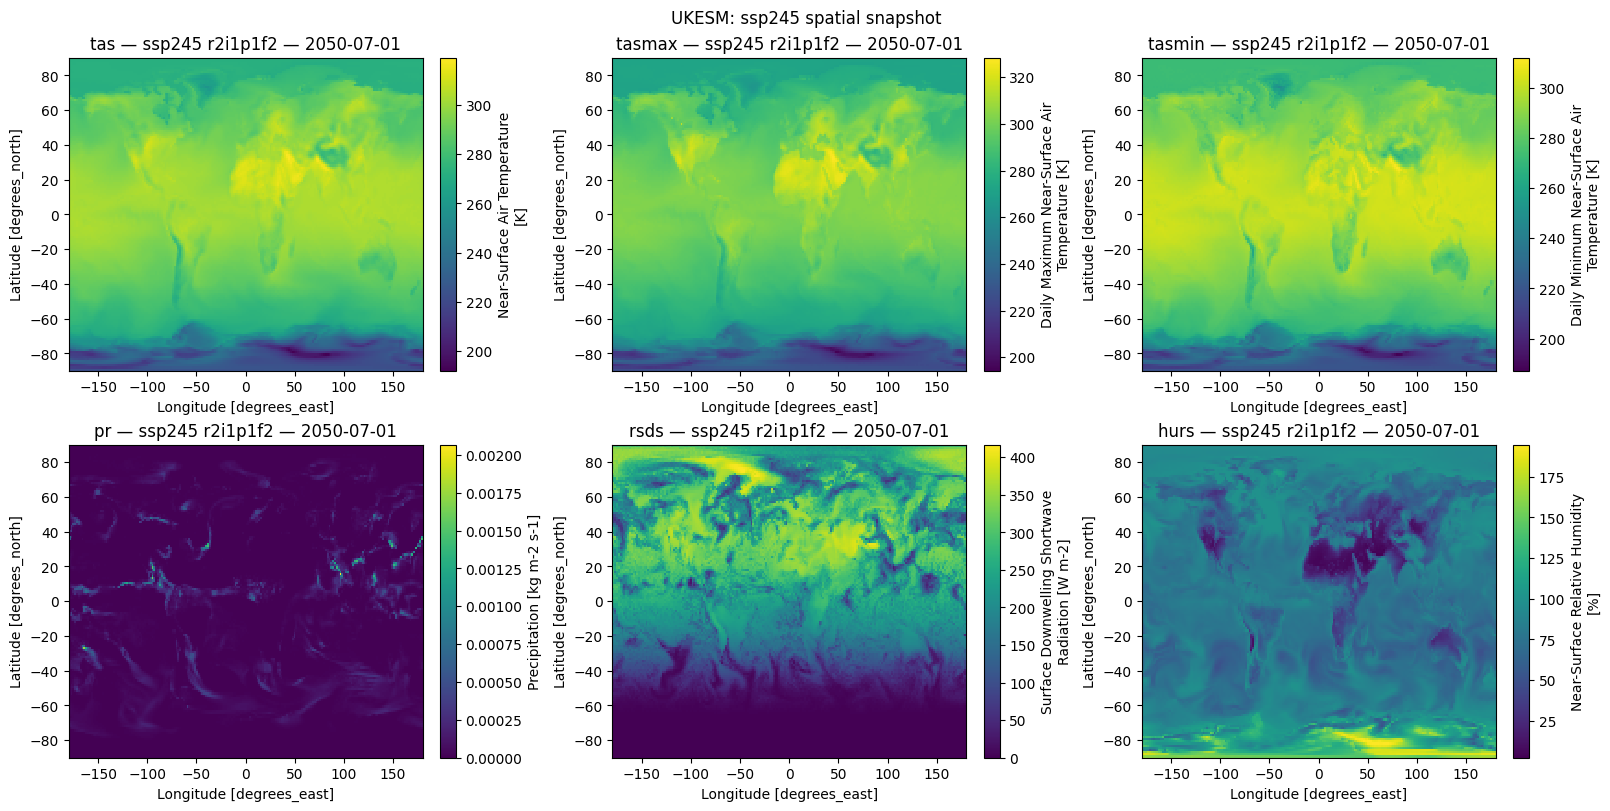

In [22]:
date = "2050-07-01"
ssp_ukesm = dt_ukesm["ssp245"].to_dataset()

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, var in zip(axes.ravel(), ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]):
    ssp_ukesm[var].sel(ensemble_member="r2i1p1f2", time=date).plot(ax=ax, cmap="viridis")
    ax.set_title(f"{var} — ssp245 r2i1p1f2 — {date}")
fig.suptitle("UKESM: ssp245 spatial snapshot");

### 4.4 `tasmax` deep-dive: grid artifacts & outlandish values

CarbonPlan/srm-downscaling#381 reports gridded spatial structure in `ssp245`/`g6_1p5k`
`tasmax` for UKESM that isn't visible in other GCMs, and #364 reports a cluster of
"outlandishly high" `tasmax` values (> 65°C) over South Africa for UKESM across all three
scenarios. A map of the **annual maximum** `tasmax` is a sensitive way to spot gridded
artifacts (real climate fields are spatially smooth; sensor/processing artifacts often
aren't), and the right panel counts how many days per pixel exceed
`qaqc.outlandishly_high_temp`'s threshold.

Outlandishly-high tasmax day-pixels in 2050 (r3i1p1f2): 7


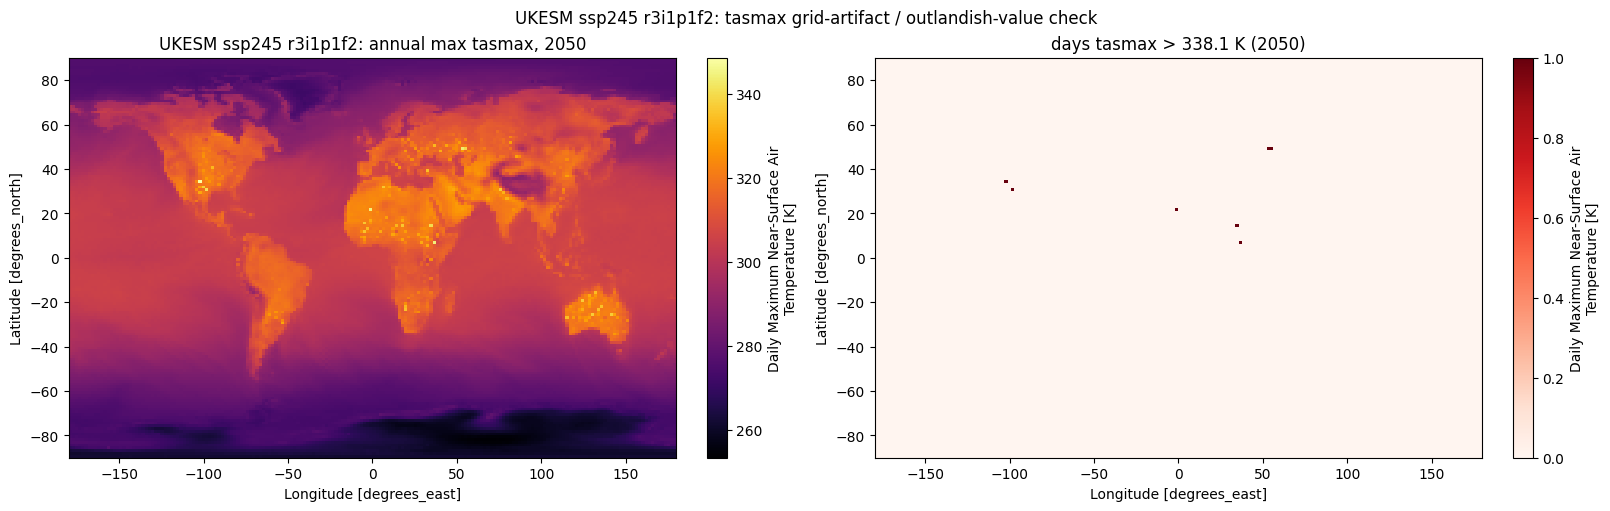

In [23]:
OUTLANDISH_TASMAX_K = 65 + 273.15  # see qaqc.outlandishly_high_temp

year = "2050"
member = "r3i1p1f2"  # member flagged in #381
tasmax_year = ssp_ukesm["tasmax"].sel(ensemble_member=member, time=year).compute()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

tasmax_year.max(dim="time").plot(ax=axes[0], cmap="inferno")
axes[0].set_title(f"UKESM ssp245 {member}: annual max tasmax, {year}")

outlandish_count = (tasmax_year > OUTLANDISH_TASMAX_K).sum(dim="time")
outlandish_count.plot(ax=axes[1], cmap="Reds")
axes[1].set_title(f"days tasmax > {OUTLANDISH_TASMAX_K:.1f} K ({year})")

fig.suptitle(f"UKESM ssp245 {member}: tasmax grid-artifact / outlandish-value check")
print(f"Outlandishly-high tasmax day-pixels in {year} ({member}): {int(outlandish_count.sum())}")

### 4.5 `ssp245` vs `g6_1p5k`: non-identical check (T/PR)

CarbonPlan/srm-downscaling#229 found that the UKESM T/PR (`tas`/`tasmax`/`tasmin`/`pr`)
files for `g6_1p5k` and `ssp245` were byte-identical for member `r2i1p1f2` -- a transfer
bug, since `validation.py::check_g6_not_identical_to_ssp245` runs in `bcsd validate`. This
spot-check is a visual echo of that regression guard: the two scenarios should diverge
over their overlapping years (2035-2084).

ssp245 vs g6_1p5k r2i1p1f2 tas, 2040: identical = False


Text(0.5, 1.0, 'UKESM r2i1p1f2 tas at (0, 0): ssp245 vs g6_1p5k (2040)')

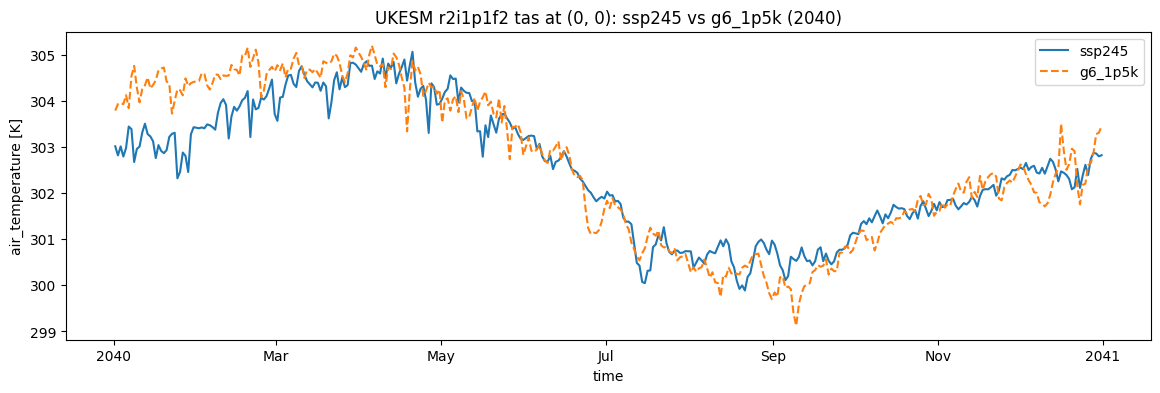

In [24]:
member = "r2i1p1f2"
year = "2040"

ssp_tas = ssp_ukesm["tas"].sel(ensemble_member=member, time=year).compute()
g6_tas = dt_ukesm["g6_1p5k"].to_dataset()["tas"].sel(ensemble_member=member, time=year).compute()

identical = bool((ssp_tas.values == g6_tas.values).all())
print(f"ssp245 vs g6_1p5k {member} tas, {year}: identical = {identical}")

fig, ax = plt.subplots(figsize=(14, 4))
ssp_tas.sel(lat=0, lon=0, method="nearest").plot(ax=ax, label="ssp245")
g6_tas.sel(lat=0, lon=0, method="nearest").plot(ax=ax, label="g6_1p5k", ls="--")
ax.legend()
ax.set_title(f"UKESM {member} tas at (0, 0): ssp245 vs g6_1p5k ({year})")

## 5. Time-coverage check across all GCM stores

Regression guard for CarbonPlan/srm-downscaling#257: the ETL converts each GCM's native
calendar (360-day for UKESM, noleap for CESM2-WACCM, gregorian for MIROC-ES2H) to
`proleptic_gregorian` via `to_proleptic_gregorian` (linear interpolation, not
`convert_calendar(align_on="date")`, which used to silently drop dates). Every
`(GCM, group)` should now have a gap-free, duplicate-free, monotonically increasing daily
time axis -- same check as ERA5 §1.2, applied across the board.

In [25]:
coverage_rows = [summarize_time_coverage(ds, "ERA5")]
for gcm_label, gcm_dt in [("CESM2-WACCM", dt), ("MIROC-ES2H", dt_miroc), ("UKESM", dt_ukesm)]:
    for group_name, node in gcm_dt.children.items():
        coverage_rows.append(
            summarize_time_coverage(node.to_dataset(), f"{gcm_label} {group_name}")
        )

coverage_df = pd.DataFrame(coverage_rows).set_index("source")


def _highlight_coverage(row):
    bad = row["n_missing"] > 0 or row["n_duplicates"] > 0 or not row["monotonic"]
    return ["background-color: #f8d7da" if bad else "" for _ in row]


coverage_df.style.apply(_highlight_coverage, axis=1)

,start,end,n_times,n_missing,n_duplicates,monotonic
source,,,,,,
ERA5,1950-01-01,2014-12-31,23741,0,0,True
CESM2-WACCM g6_1p5k,2035-01-01,2085-01-01,18264,0,0,True
CESM2-WACCM historical,1850-01-01,2015-01-16,60281,0,0,True
CESM2-WACCM ssp245,2015-01-01,2099-12-31,31046,0,0,True
MIROC-ES2H esgf_ssp245,2015-01-01,2099-12-31,31046,0,0,True
MIROC-ES2H g6_1p5k,2035-01-01,2084-12-31,18263,0,0,True
MIROC-ES2H ssp245,2015-01-01,2084-12-31,25568,0,0,True
MIROC-ES2H historical,1850-01-01,2014-12-31,60265,0,0,True
UKESM g6_1p5k,2035-01-01,2084-12-31,18263,0,0,True


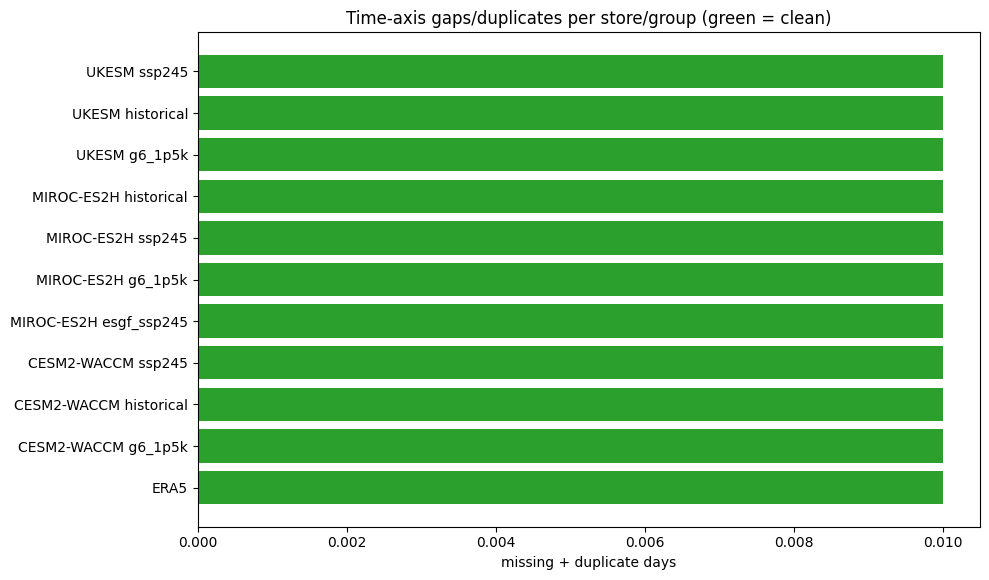

In [26]:
fig, ax = plt.subplots(figsize=(10, 0.4 * len(coverage_df) + 1.5))
gap_counts = coverage_df["n_missing"] + coverage_df["n_duplicates"]
colors = [
    "tab:red" if (gaps > 0 or not mono) else "tab:green"
    for gaps, mono in zip(gap_counts, coverage_df["monotonic"])
]
ax.barh(coverage_df.index, gap_counts.clip(lower=0.01), color=colors)
ax.set_xlabel("missing + duplicate days")
ax.set_title("Time-axis gaps/duplicates per store/group (green = clean)")
plt.tight_layout()

## 6. Units & reasonable-range check (all sources)

Per CarbonPlan/srm-downscaling#316/#384: check the declared `units` attribute and the
global min/max on a single date for every variable in every store against
`REASONABLE_RANGES`. This is exactly the kind of check that would have caught #318
(`hurs` off by 1000x in CESM) and #299 (`pr` off by 1000x vs. ERA5) earlier, and gives a
running check on #358 (unrealistically high raw `hurs`, expected to occasionally exceed
the `max_range` upper bound).

In [27]:
hist_miroc = dt_miroc["historical"].to_dataset()
hist_ukesm = dt_ukesm["historical"].to_dataset()
g6_miroc = dt_miroc["g6_1p5k"].to_dataset()
g6_cesm = dt["g6_1p5k"].to_dataset()
g6_ukesm = dt_ukesm["g6_1p5k"].to_dataset()


range_rows = []
range_rows += check_units_and_range(ds, "ERA5", isel_kwargs=_sample_kwargs(ds))
range_rows += check_units_and_range(
    hist_cesm, "CESM2-WACCM historical", isel_kwargs=_sample_kwargs(hist_cesm)
)
range_rows += check_units_and_range(
    ssp_cesm, "CESM2-WACCM ssp245", isel_kwargs=_sample_kwargs(ssp_cesm)
)
range_rows += check_units_and_range(g6_cesm, "CESM2-WACCM g6", isel_kwargs=_sample_kwargs(g6_cesm))
range_rows += check_units_and_range(
    hist_miroc, "MIROC-ES2H historical", isel_kwargs=_sample_kwargs(hist_miroc)
)
range_rows += check_units_and_range(
    ssp_miroc, "MIROC-ES2H ssp245", isel_kwargs=_sample_kwargs(ssp_miroc)
)
range_rows += check_units_and_range(g6_miroc, "MIROC-ES2H g6", isel_kwargs=_sample_kwargs(g6_miroc))
range_rows += check_units_and_range(
    hist_ukesm, "UKESM historical", isel_kwargs=_sample_kwargs(hist_ukesm)
)
range_rows += check_units_and_range(
    ssp_ukesm, "UKESM ssp245", isel_kwargs=_sample_kwargs(ssp_ukesm)
)
range_rows += check_units_and_range(g6_ukesm, "UKESM g6", isel_kwargs=_sample_kwargs(g6_ukesm))

range_df = pd.DataFrame(range_rows)
(
    range_df.style.map(highlight_fail, subset=["min_ok", "max_ok"]).format(
        {"min": "{:.4g}", "max": "{:.4g}"}
    )
)

,source,variable,units,min,max,min_ok,max_ok
0,ERA5,tas,K,203.5,314.5,True,True
1,ERA5,tasmin,K,200.7,307.9,True,True
2,ERA5,tasmax,K,205.3,322.1,True,True
3,ERA5,pr,kg m-2 s-1,0,0.003843,True,True
4,ERA5,rsds,W m-2,-6.104e-05,408.5,True,True
5,ERA5,hurs,%,4.105,99.99,True,True
6,CESM2-WACCM historical,tas,K,200.4,315.8,True,True
7,CESM2-WACCM historical,tasmin,K,204.2,307.1,True,True
8,CESM2-WACCM historical,tasmax,K,208.1,317.9,True,True
9,CESM2-WACCM historical,pr,kg m-2 s-1,0,0.001916,True,True


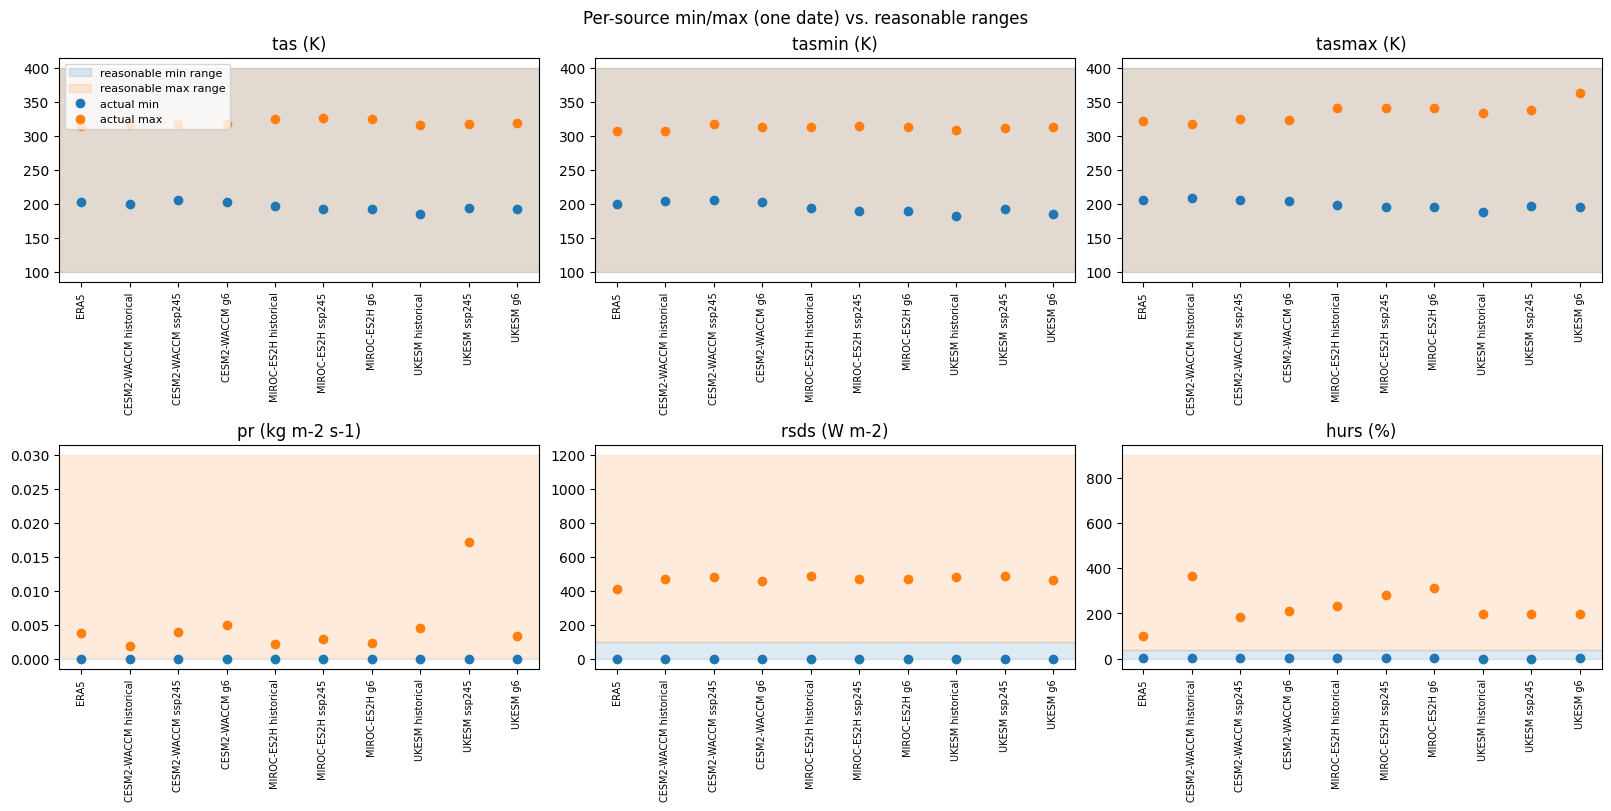

In [28]:
variables = list(qaqc.VAR_SPATIAL_RANGES)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, var in zip(axes.ravel(), variables):
    sub = range_df[range_df["variable"] == var]
    ranges = qaqc.VAR_SPATIAL_RANGES[var]
    units = sub["units"].dropna().iloc[0] if len(sub) > 0 and sub["units"].notna().any() else ""
    ax.axhspan(*ranges["min"], color="tab:blue", alpha=0.15, label="reasonable min range")
    ax.axhspan(*ranges["max"], color="tab:orange", alpha=0.15, label="reasonable max range")
    ax.plot(sub["source"], sub["min"], "o", color="tab:blue", label="actual min")
    ax.plot(sub["source"], sub["max"], "o", color="tab:orange", label="actual max")
    ax.set_title(f"{var} ({units})")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Per-source min/max (one date) vs. reasonable ranges");

## 7. Lat/lon grid check (all sources)

Per CarbonPlan/srm-downscaling#316: every store should be **global** (`lat` in
`[-90, 90]`, `lon` in `[-180, 180]`) with a monotonic coordinate axis, and all
scenarios/groups for a given GCM should share the same native grid. The table below
summarizes extent/resolution/monotonicity per `(source, group)`, and the scatter plot
shows the actual grid-cell centers (subsampled) so resolution and global coverage
differences between sources are visible at a glance.

In [29]:
grid_rows = [summarize_grid(ds, "ERA5")]
for gcm_label, gcm_dt in [("CESM2-WACCM", dt), ("MIROC-ES2H", dt_miroc), ("UKESM", dt_ukesm)]:
    for group_name, node in gcm_dt.children.items():
        grid_rows.append(summarize_grid(node.to_dataset(), f"{gcm_label} {group_name}"))

grid_df = pd.DataFrame(grid_rows).set_index("source")
grid_df["grid_ok"] = (
    grid_df["lat_monotonic"]
    & grid_df["lon_monotonic"]
    & grid_df["lat_range_ok"]
    & grid_df["lon_range_ok"]
)
grid_df.style.apply(highlight_row_fail("grid_ok"), axis=1)

,lat_min,lat_max,lon_min,lon_max,n_lat,n_lon,lat_res,lon_res,lat_monotonic,lon_monotonic,lat_range_ok,lon_range_ok,grid_ok
source,,,,,,,,,,,,,
ERA5,-90.000000,90.000000,-180.000000,179.750000,721,1440,0.250000,0.250000,True,True,True,True,True
CESM2-WACCM g6_1p5k,-90.000000,90.000000,-180.000000,178.750000,192,288,0.942408,1.250000,True,True,True,True,True
CESM2-WACCM historical,-90.000000,90.000000,-180.000000,178.750000,192,288,0.942408,1.250000,True,True,True,True,True
CESM2-WACCM ssp245,-90.000000,90.000000,-180.000000,178.750000,192,288,0.942408,1.250000,True,True,True,True,True
MIROC-ES2H esgf_ssp245,-88.927735,88.927735,-180.000000,178.593750,128,256,1.400437,1.406250,True,True,True,True,True
MIROC-ES2H g6_1p5k,-88.927735,88.927735,-180.000000,178.593750,128,256,1.400437,1.406250,True,True,True,True,True
MIROC-ES2H ssp245,-88.927735,88.927735,-180.000000,178.593750,128,256,1.400437,1.406250,True,True,True,True,True
MIROC-ES2H historical,-88.927735,88.927735,-180.000000,178.593750,128,256,1.400437,1.406250,True,True,True,True,True
UKESM g6_1p5k,-89.375000,89.375000,-179.062500,179.062500,144,192,1.250000,1.875000,True,True,True,True,True


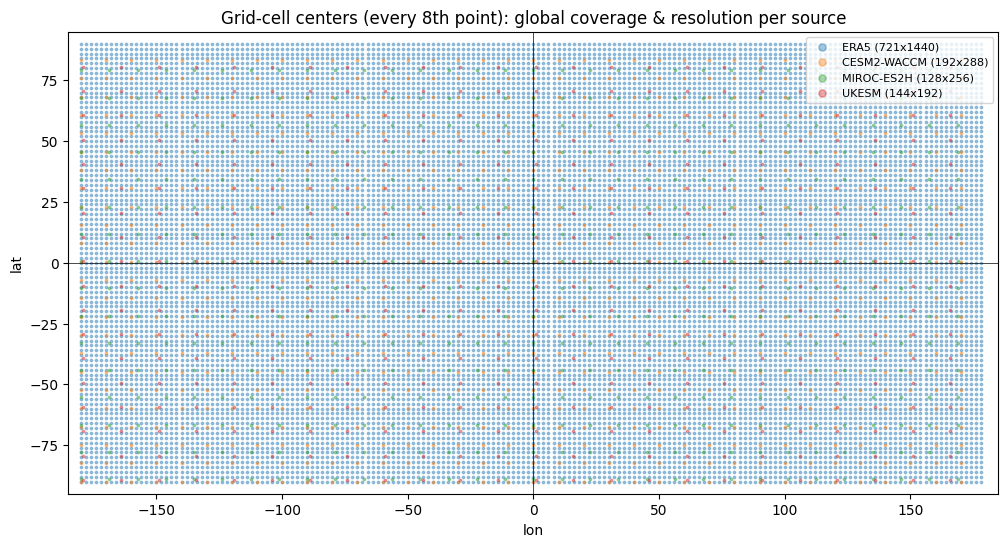

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
grid_sources = {
    f"ERA5 ({ds.sizes['lat']}x{ds.sizes['lon']})": ds,
    f"CESM2-WACCM ({hist_cesm.sizes['lat']}x{hist_cesm.sizes['lon']})": hist_cesm,
    f"MIROC-ES2H ({hist_miroc.sizes['lat']}x{hist_miroc.sizes['lon']})": hist_miroc,
    f"UKESM ({hist_ukesm.sizes['lat']}x{hist_ukesm.sizes['lon']})": hist_ukesm,
}
for label, src_ds in grid_sources.items():
    lon_grid, lat_grid = np.meshgrid(src_ds.lon.values[::8], src_ds.lat.values[::8])
    ax.scatter(lon_grid.ravel(), lat_grid.ravel(), s=3, alpha=0.4, label=label)

ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(-185, 185)
ax.set_ylim(-95, 95)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title("Grid-cell centers (every 8th point): global coverage & resolution per source")
ax.legend(markerscale=3, fontsize=8);

## 8. Ensemble-spread check (all GCM groups)

Per CarbonPlan/srm-downscaling#316: distinct ensemble members should produce distinct
results -- e.g. `tas` member `001` should differ from member `002`. The table flags any
`(GCM, group)` where two or more members share an (almost) identical global-mean `tas` on
a single date, and the bar charts make this visible directly: flat/identical bars across
members within a group would indicate the same source file got loaded for multiple
members.

In [31]:
spread_rows = []
for gcm_label, gcm_dt in [("CESM2-WACCM", dt), ("MIROC-ES2H", dt_miroc), ("UKESM", dt_ukesm)]:
    for group_name, node in gcm_dt.children.items():
        spread_rows.append(check_ensemble_spread(node.to_dataset(), f"{gcm_label} {group_name}"))

spread_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in ("members", "means")} for row in spread_rows]
).set_index("source")
spread_df.style.apply(highlight_row_fail("spread_ok"), axis=1)

,variable,spread_ok
source,,
CESM2-WACCM g6_1p5k,tas,True
CESM2-WACCM historical,tas,True
CESM2-WACCM ssp245,tas,True
MIROC-ES2H esgf_ssp245,tas,True
MIROC-ES2H g6_1p5k,tas,True
MIROC-ES2H ssp245,tas,False
MIROC-ES2H historical,tas,True
UKESM g6_1p5k,tas,True
UKESM historical,tas,True


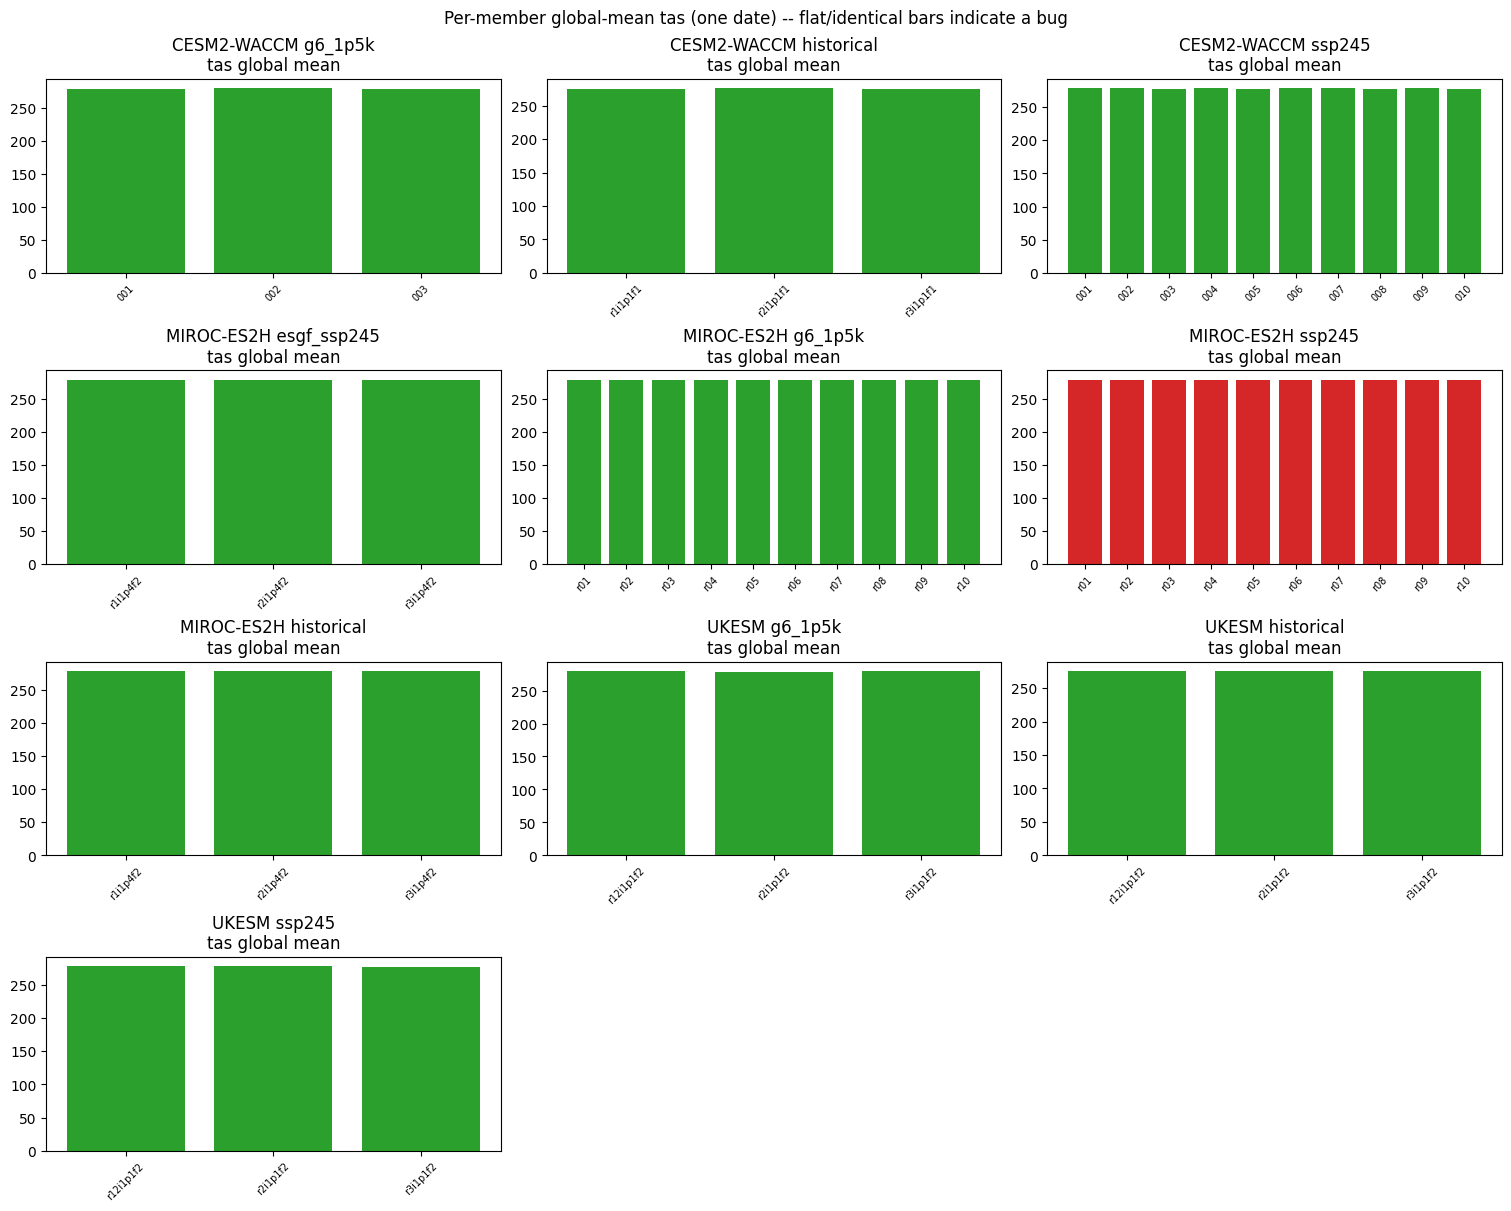

In [32]:
ncols = 3
nrows = -(-len(spread_rows) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), constrained_layout=True)
for ax, row in zip(axes.ravel(), spread_rows):
    ax.bar(row["members"], row["means"], color="tab:green" if row["spread_ok"] else "tab:red")
    ax.set_title(f"{row['source']}\n{row['variable']} global mean")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
for ax in axes.ravel()[len(spread_rows) :]:
    ax.axis("off")
fig.suptitle("Per-member global-mean tas (one date) -- flat/identical bars indicate a bug");

## 9. Calendar check (all GCM groups)

Regression guard: every group's time coordinate must be decoded as `numpy.datetime64`
with `proleptic_gregorian` calendar after the ETL's `to_proleptic_gregorian` conversion.
A `cftime` dtype here would silently break downstream xarray operations that assume
`numpy.datetime64`. The table flags any group whose calendar or dtype is unexpected.

In [33]:
from srm.qaqc import DatasetChecker

cal_rows = []
for gcm_label, gcm_dt in [("CESM2-WACCM", dt), ("MIROC-ES2H", dt_miroc), ("UKESM", dt_ukesm)]:
    for group_name, node in gcm_dt.children.items():
        ds_grp = node.to_dataset()
        calendar = getattr(ds_grp.time.dt, "calendar", None)
        dtype_ok = bool(np.issubdtype(ds_grp.time.dtype, np.datetime64))
        cal_ok = calendar == "proleptic_gregorian"
        cal_rows.append(
            {
                "source": f"{gcm_label} {group_name}",
                "calendar": calendar,
                "dtype": str(ds_grp.time.dtype),
                "calendar_ok": cal_ok,
                "dtype_ok": dtype_ok,
                "ok": cal_ok and dtype_ok,
            }
        )

cal_df = pd.DataFrame(cal_rows).set_index("source")
cal_df.style.apply(highlight_row_fail("ok"), axis=1)

,calendar,dtype,calendar_ok,dtype_ok,ok
source,,,,,
CESM2-WACCM g6_1p5k,proleptic_gregorian,datetime64[ns],True,True,True
CESM2-WACCM historical,proleptic_gregorian,datetime64[ns],True,True,True
CESM2-WACCM ssp245,proleptic_gregorian,datetime64[ns],True,True,True
MIROC-ES2H esgf_ssp245,proleptic_gregorian,datetime64[ns],True,True,True
MIROC-ES2H g6_1p5k,proleptic_gregorian,datetime64[ns],True,True,True
MIROC-ES2H ssp245,proleptic_gregorian,datetime64[ns],True,True,True
MIROC-ES2H historical,proleptic_gregorian,datetime64[ns],True,True,True
UKESM g6_1p5k,proleptic_gregorian,datetime64[ns],True,True,True
UKESM historical,proleptic_gregorian,datetime64[ns],True,True,True


## 10. DTR consistency check (all GCM groups)

Checks that `dtr == tasmax − tasmin` within a tolerance of 0.5 K across a representative
sample of time steps and ensemble members. Skipped for groups that lack all three of `dtr`,
`tasmax`, `tasmin`. A failure indicates a processing error in the ETL's derived-variable
computation — the `dtr` variable was not computed from the correct source fields.

In [34]:
dtr_rows = []
for gcm_label, gcm_dt in [("CESM2-WACCM", dt), ("MIROC-ES2H", dt_miroc), ("UKESM", dt_ukesm)]:
    for group_name, node in gcm_dt.children.items():
        ds_grp = node.to_dataset()
        if not {"dtr", "tasmax", "tasmin"}.issubset(ds_grp.data_vars):
            dtr_rows.append(
                {"source": f"{gcm_label} {group_name}", "ok": True, "issues": "skip — no dtr"}
            )
            continue
        vr = DatasetChecker(ds_grp).validate_dtr_consistency(isel_kwargs=_sample_kwargs(ds_grp))
        dtr_rows.append(
            {
                "source": f"{gcm_label} {group_name}",
                "ok": bool(vr),
                "issues": "; ".join(vr.issues) if not vr else "",
            }
        )

dtr_df = pd.DataFrame(dtr_rows).set_index("source")
dtr_df.style.apply(highlight_row_fail("ok"), axis=1)

,ok,issues
source,,
CESM2-WACCM g6_1p5k,True,skip — no dtr
CESM2-WACCM historical,True,skip — no dtr
CESM2-WACCM ssp245,True,skip — no dtr
MIROC-ES2H esgf_ssp245,True,skip — no dtr
MIROC-ES2H g6_1p5k,True,skip — no dtr
MIROC-ES2H ssp245,True,skip — no dtr
MIROC-ES2H historical,True,skip — no dtr
UKESM g6_1p5k,True,skip — no dtr
UKESM historical,True,skip — no dtr


## 11. No-identical-vars check (all GCM groups)

Regression guard for copy-paste or ETL merge bugs: no two variables in the same group
should be byte-identical across a sample of time steps. For example, `tas` and `tasmax`
being identical would indicate the same source variable was written under two names.
Uses `_resolve_ensemble_member` internally to pick the first non-null member before
sampling, and skips all-NaN variable pairs automatically.

In [35]:
ident_rows = []
for gcm_label, gcm_dt in [("CESM2-WACCM", dt), ("MIROC-ES2H", dt_miroc), ("UKESM", dt_ukesm)]:
    for group_name, node in gcm_dt.children.items():
        ds_grp = node.to_dataset()
        vr = DatasetChecker(ds_grp).validate_no_identical_vars()
        ident_rows.append(
            {
                "source": f"{gcm_label} {group_name}",
                "ok": bool(vr),
                "issues": "; ".join(vr.issues) if not vr else "",
            }
        )

ident_df = pd.DataFrame(ident_rows).set_index("source")
ident_df.style.apply(highlight_row_fail("ok"), axis=1)

,ok,issues
source,,
CESM2-WACCM g6_1p5k,True,
CESM2-WACCM historical,True,
CESM2-WACCM ssp245,False,tas and tasmin are identical across 15 consecutive time steps; tas and tasmax are identical across 15 consecutive time steps; tasmin and tasmax are identical across 15 consecutive time steps
MIROC-ES2H esgf_ssp245,True,
MIROC-ES2H g6_1p5k,True,
MIROC-ES2H ssp245,True,
MIROC-ES2H historical,True,
UKESM g6_1p5k,True,
UKESM historical,True,


## 12. Cross-GCM comparison

CESM2-WACCM (`192 x 288`), MIROC-ES2H (`128 x 256`), UKESM1-0-LL (`144 x 192`), and ERA5
(`721 x 1440`) are on different native grids — that's expected here, since regridding to a
common grid is the job of `prepare_observations` in the BCSD pipeline, not these ETL
stores. This section is just a visual gut-check that the three GCMs' `historical` `tas`
fields are in the right ballpark and show the same broad spatial pattern for an
overlapping date.


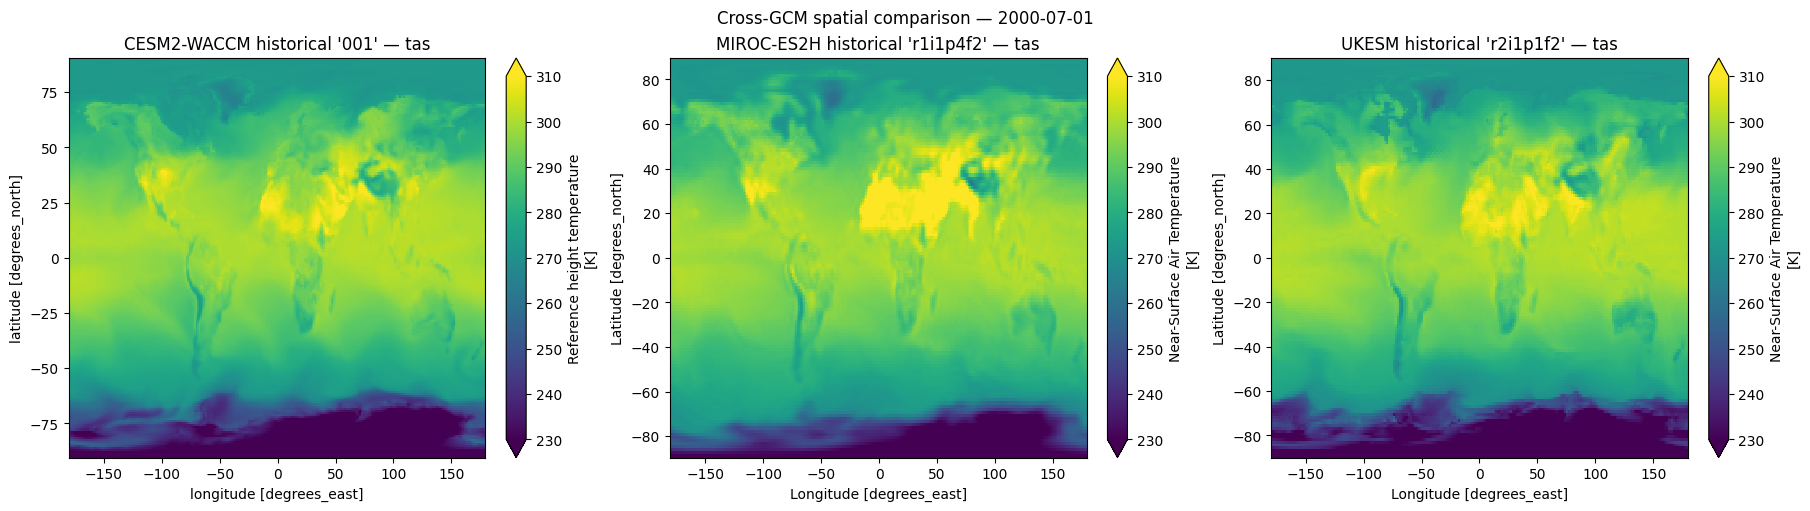

In [36]:
date = "2000-07-01"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
hist_cesm["tas"].sel(ensemble_member="001", time=date).plot(ax=axes[0], vmin=230, vmax=310)
axes[0].set_title("CESM2-WACCM historical '001' — tas")

hist_miroc["tas"].sel(ensemble_member="r1i1p4f2", time=date).plot(ax=axes[1], vmin=230, vmax=310)
axes[1].set_title("MIROC-ES2H historical 'r1i1p4f2' — tas")

hist_ukesm["tas"].sel(ensemble_member="r2i1p1f2", time=date).plot(ax=axes[2], vmin=230, vmax=310)
axes[2].set_title("UKESM historical 'r2i1p1f2' — tas")

fig.suptitle(f"Cross-GCM spatial comparison — {date}");

## 13. Summary checklist

Use this checklist while reviewing the outputs above:

- [ ] **ERA5**: time axis is gap-free and monotonic (1950-01-01 → 2014-12-31, no
  duplicates).
- [ ] **ERA5**: spatial fields look physically plausible (no obvious striping/blank
  regions).
- [ ] **ERA5**: `qaqc.check_physical_constraints` reports zero violations for the 2010
  subset.
- [ ] **CESM2-WACCM `historical`**: NaN coverage matches expectations — `'001'` is NaN
  outside 1978–2015 for all variables; Pangeo members (`r*i1p1f1`) are NaN for
  `tasmax`/`tasmin` everywhere and for `tas`/`pr`/`rsds`/`hurs` outside 1850–2015.
- [ ] **CESM2-WACCM `historical`**: `'001'` vs `'r1i1p1f1'` `tas` fields are spatially
  consistent (similar magnitude/pattern, not identical — different ensemble members).
- [ ] **CESM2-WACCM `ssp245`**: all 6 variables (`hurs`, `pr`, `rsds`, `tas`, `tasmax`,
  `tasmin`) present across all 10 members, 2015–2101, with no structural NaNs.
- [ ] **MIROC-ES2H `ssp245`**: no NaN gap around the 2015–2020 stitch boundary, and the
  `tas` time series is continuous (no jump/discontinuity) across 2020-01-01.
- [ ] **UKESM `ssp245`/`g6_1p5k`**: all 6 variables share the same 3-member
  `ensemble_member` coordinate (`r2i1p1f2`, `r3i1p1f2`, `r12i1p1f2`) and the same clipped
  time range (`ssp245`: 2015–2099, `g6_1p5k`: 2035–2084), with ~0% structural NaNs.
- [ ] **UKESM**: no leftover UM suite IDs (e.g. `u-dp583`) or unmapped legacy `ripf`
  labels (e.g. `r2i1p1f1`) in any group's `ensemble_member` coordinate.
- [ ] **Cross-GCM**: CESM2-WACCM (`192x288`), MIROC-ES2H (`128x256`), and UKESM1-0-LL
  (`144x192`) historical `tas` fields show the same broad spatial pattern as ERA5
  (`721x1440`) for the same date.
- [ ] **UKESM `tasmax`**: the annual-max map (§4.4) shows a smooth spatial pattern with no
  gridded/checkerboard artifacts (#381), and the outlandish-value count is 0 or limited to
  the small known region from #364.
- [ ] **UKESM `ssp245` vs `g6_1p5k`**: `tas` time series for `r2i1p1f2` diverge over their
  overlapping years (`identical = False` in §4.5) -- regression guard for #229.
- [ ] **Time-coverage**: every `(GCM, group)` row in §5 is gap-free, duplicate-free, and
  monotonic (no red rows) -- regression guard for #257.
- [ ] **Units & ranges**: every row in §6 has `units_ok`/`min_ok`/`max_ok` all `True`
  (no red cells), except any expected/known exceptions (e.g. `hurs` `max_ok` exceeding
  the upper bound per #358).
- [ ] **Lat/lon grid**: every row in §7 has `grid_ok = True` (global coverage,
  monotonic axes, no red rows), and the §7 scatter plot shows each GCM's grid resolution
  as expected (CESM2-WACCM `192x288`, MIROC-ES2H `128x256`, UKESM `144x192`,
  ERA5 `721x1440`).
- [ ] **Ensemble spread**: every row in §8 has `spread_ok = True` (no red rows/bars) --
  each ensemble member has a distinct global-mean `tas`.
- [ ] **Calendar** (§9): every `(GCM, group)` row has `ok = True` — `proleptic_gregorian`
  calendar and `datetime64` dtype (no red rows) — regression guard for calendar-conversion
  failures in `to_proleptic_gregorian`.
- [ ] **DTR consistency** (§10): every row with a `dtr` variable has `ok = True` —
  `dtr` deviates from `tasmax − tasmin` by no more than 0.5 K (no red rows).
- [ ] **No identical vars** (§11): every `(GCM, group)` row has `ok = True` — no two
  variables are byte-identical across sampled time steps (no red rows).

### 13.1 Physical-constraint checks (CESM2-WACCM, MIROC-ES2H & UKESM, one member/year)

In [37]:
print("CESM2-WACCM historical '001', 2000:")
qaqc.check_physical_constraints(hist_cesm.sel(ensemble_member="001", time="2000").compute())

print("\nMIROC-ES2H historical 'r1i1p4f2', 2000:")
qaqc.check_physical_constraints(hist_miroc.sel(ensemble_member="r1i1p4f2", time="2000").compute())

print("\nUKESM historical 'r2i1p1f2', 2000:")
qaqc.check_physical_constraints(hist_ukesm.sel(ensemble_member="r2i1p1f2", time="2000").compute())

CESM2-WACCM historical '001', 2000:
Number of negative precipitation values: 0
Number of outlandishly high precipitation values: 0
Number of outlandishly high tas values: 0
Number of outlandishly high tasmax values: 0
Number of outlandishly high tasmin values: 0
Number of outlandishly low tas values: 0
Number of outlandishly low tasmax values: 0
Number of outlandishly low tasmin values: 0
Number of times tasmin exceeds tas: 0
Number of times tas exceeds tasmax: 0
Number of times tasmin exceeds tasmax: 0

MIROC-ES2H historical 'r1i1p4f2', 2000:
Number of negative precipitation values: 0
Number of outlandishly high precipitation values: 0
Number of outlandishly high tas values: 0
Number of outlandishly high tasmax values: 429
Number of outlandishly high tasmin values: 0
Number of outlandishly low tas values: 0
Number of outlandishly low tasmax values: 0
Number of outlandishly low tasmin values: 0
Number of times tasmin exceeds tas: 0
Number of times tas exceeds tasmax: 0
Number of times 